In [3]:
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('BlackFriday.csv')

In [6]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [10]:
df.isnull().sum()


User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

# Removing Product_Category_2 & Product_Category_3

In [7]:
del df['Product_Category_2']      # if Error - it alredy deleted
del df['Product_Category_3']

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category_1          537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


#  

In [31]:
df['User_ID'].nunique()

5891

In [33]:
df['Product_ID'].nunique()

3623

In [45]:
print(df['Gender'].nunique())
print(df['Gender'].unique())

2
['F' 'M']


In [43]:
print(df['Age'].nunique())
print(df['Age'].unique())

7
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']


In [47]:
df['Occupation'].nunique()

21

In [49]:
print(df['Stay_In_Current_City_Years'].nunique())
print(df['Stay_In_Current_City_Years'].unique())

5
['2' '4+' '3' '1' '0']


In [51]:
print(df['Marital_Status'].nunique())
print(df['Marital_Status'].unique())

2
[0 1]


In [55]:
print(df['Product_Category_1'].nunique())

18


In [57]:
df['Purchase'].sum()

5017668378

In [16]:
for i in df.columns:
    if i=='Purchase':
        continue
    print(i, "--", df[i].nunique())

User_ID -- 5891
Product_ID -- 3623
Gender -- 2
Age -- 7
Occupation -- 21
City_Category -- 3
Stay_In_Current_City_Years -- 5
Marital_Status -- 2
Product_Category_1 -- 18


# Analyzing Age

### Naive Mathod to make Ratio

<Axes: title={'center': 'Age Proportions'}, ylabel='Ratio'>

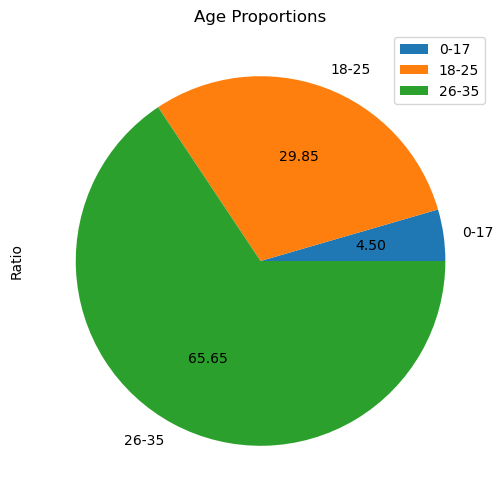

In [21]:
data = pd.DataFrame ({'Ratio' : [len(df[df['Age'] == '0-17']), len(df[df['Age'] == '18-25']), len(df[df['Age'] == '26-35'])]},
                    index = ['0-17','18-25','26-35'])
data.plot(kind = 'pie', y = 'Ratio', 
          autopct='%.2f', figsize = (6,6),
         title = 'Age Proportions')

### Better Method - Groupby

<Axes: title={'center': 'Age Proportions'}>

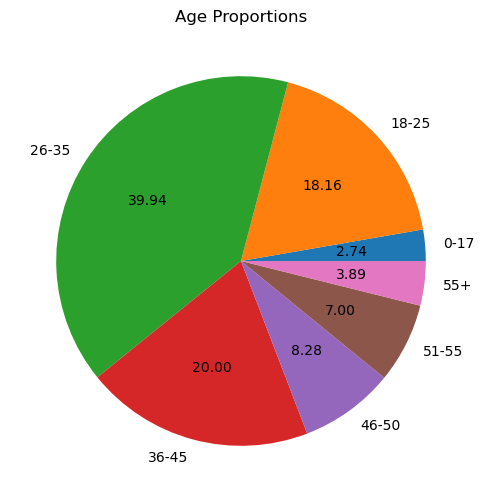

In [23]:
data = df.groupby('Age').size()

data.plot(kind='pie', y='Age',
         autopct='%.2f', title='Age Proportions',
        figsize = (6,6))

<Axes: title={'center': 'Age Proportions'}, xlabel='Age'>

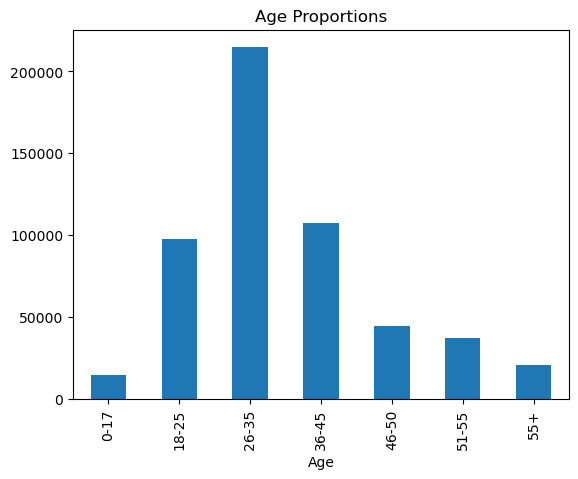

In [25]:
data.plot(kind='bar', y='Age',
         title='Age Proportions')

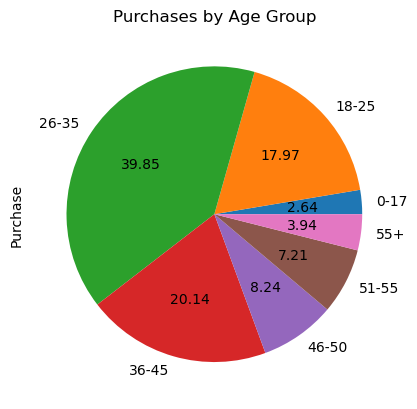

In [27]:
data1 = df.groupby('Age').sum()['Purchase'].plot(kind='pie',autopct='%.2f',title='Purchases by Age Group')

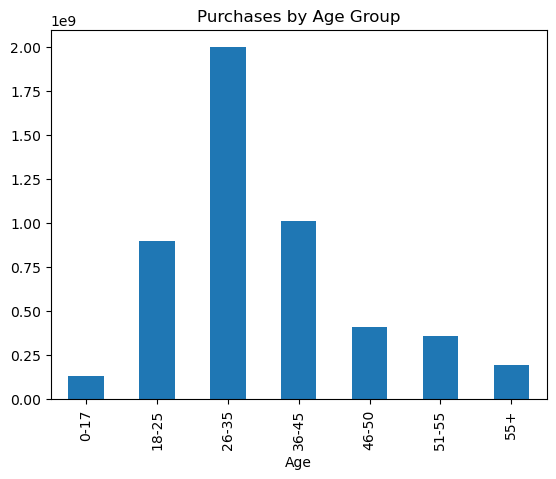

In [62]:
data1 = df.groupby('Age').sum()['Purchase'].plot(kind='bar',title='Purchases by Age Group')

#### data1 = df.groupby('Age').mean()['Purchase'].plot(kind='pie',autopct='%.2f',title='Purchases by Age Group') # erreo

In [ ]:
data2 = df.groupby('Gender').sum()['Purchase'].plot(kind='pie',autopct='%.2f',title='Purchases by Gender')

In [78]:
df.sample(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
2897,1000466,P00120542,M,26-35,5,A,2,0,8,7758
73264,1005283,P00279542,M,18-25,2,C,1,1,8,10042
121011,1000710,P00109242,M,26-35,20,A,4+,0,6,16517
534255,1004261,P00119142,F,36-45,6,C,3,0,3,10612
292633,1003141,P00295942,M,26-35,14,C,3,1,2,13011
12322,1001860,P00209842,M,55+,16,C,1,0,5,3471
97078,1003039,P00100042,F,51-55,3,C,0,1,6,19940
436979,1001271,P00121642,F,46-50,6,C,3,1,5,8736
198404,1000651,P00273742,M,36-45,7,B,2,0,1,15504
344835,1005074,P00121142,M,0-17,0,B,2,0,8,8119


In [11]:
for i in df['Age'].unique():
    print(i, ':', len(df[df['Age'] == i]))

0-17 : 14707
55+ : 20903
26-35 : 214690
46-50 : 44526
51-55 : 37618
36-45 : 107499
18-25 : 97634


In [13]:
data = pd.DataFrame ({'Ratio' : [len(df[df['Age'] == '0-17']), len(df[df['Age'] == '18-25']), len(df[df['Age'] == '26-35'])]},
                    index = ['0-17','18-25','26-35'])

In [15]:
data

,Ratio
0-17,14707
18-25,97634
26-35,214690


In [112]:
data = pd.DataFrame(
    {#'Customers' : [len(df[df['Age'] == i]) for i in df['Age'].unique()],
    'City A' : [len(df[(df['City_Category'] == 'A') & (df['Age'] == i)]) for i in df['Age'].unique()],
    'City B' : [len(df[(df['Age'] == i) & (df['City_Category'] == 'B')]) for i in df['Age'].unique()],
    'City C' : [len(df[(df['Age'] == i) & (df['City_Category'] == 'C')]) for i in df['Age'].unique()]},
    index = df['Age'].unique()
).sort_index()
data

## Since the age values are strings in this case, the `.sort_index()` method will:
## 1. Sort the DataFrame rows based on lexicographical (alphabetical) ordering of the string age values in the index
## 2. This means age values will be ordered like: "0-17", "18-25", "26-35", "36-45", etc. (if they follow this format)

,City A,City B,City C
0-17,2497,5288,6922
18-25,27025,42470,28139
26-35,72048,89767,52875
36-45,26142,46605,34752
46-50,7467,19900,17159
51-55,5969,17435,14214
55+,3490,5028,12385


### Distribution of Sales in Different Cities of specific Age Groups

In [ ]:
data.plot(kind = 'bar',
        title = 'Distribution of Sales in Different Cities of specific Age Groups'
)

## The x and y axes are not explicitly specified in the `data.plot()` call because:
## 1. Pandas automatically uses the DataFrame's index (the age values) as the x-axis categories for the bar chart without needing to specify it.
## 2. The y-axis values are automatically taken from the DataFrame's columns (City A, City B, and City C), with each column becoming a separate set of bars in the plot.

In [76]:
print('Population of City A : ', data['City A'].sum())
print('Population of City B : ', data['City B'].sum())
print('Population of City C : ',data['City C'].sum())

Population of City A :  144638
Population of City B :  226493
Population of City C :  166446


In [106]:
df['Purchase'].sum()

5017668378

In [116]:
data1 = data.copy(deep=True)

In [130]:
data1['Purchase Amt'] = [df[df['Age'] == i]['Purchase'].sum() for i in df['Age'].unique()]
data1['Customers'] = [len(df[df['Age'] == i]) for i in df['Age'].unique()]
data1['Mean Purchase Amt'] = [df[df['Age'] == i]['Purchase'].mean() for i in df['Age'].unique()]

In [136]:
data1

,City A,City B,City C,Customers,Purchase Amt,Mean Purchase Amt
0-17,2497,5288,6922,14707,132659006,9020.126878
18-25,27025,42470,28139,20903,197614842,9453.898579
26-35,72048,89767,52875,214690,1999749106,9314.588970
36-45,26142,46605,34752,44526,413418223,9284.872277
46-50,7467,19900,17159,37618,361908356,9620.616620
51-55,5969,17435,14214,107499,1010649565,9401.478758
55+,3490,5028,12385,97634,901669280,9235.197575


 ## Multi column Analysis

In [46]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


Text(0.5, 1.0, 'Gender Proportions as per Age Group')

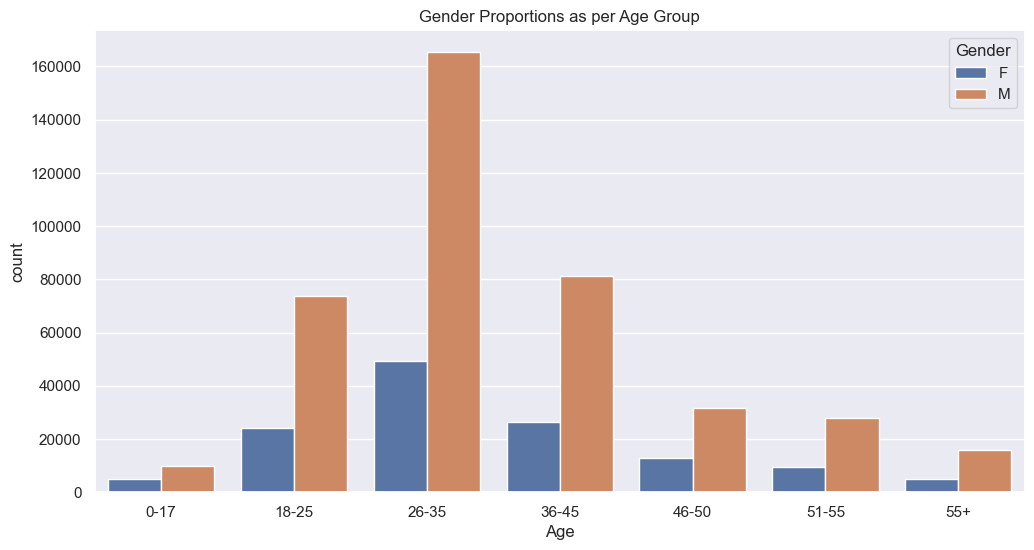

In [44]:
sns.set(rc = {'figure.figsize':(12,6)})
ax = sns.countplot(x = "Age", hue = "Gender", data = df, order=sorted(df["Age"]))
ax.set_title("Gender Proportions as per Age Group")

<Axes: xlabel='City_Category', ylabel='count'>

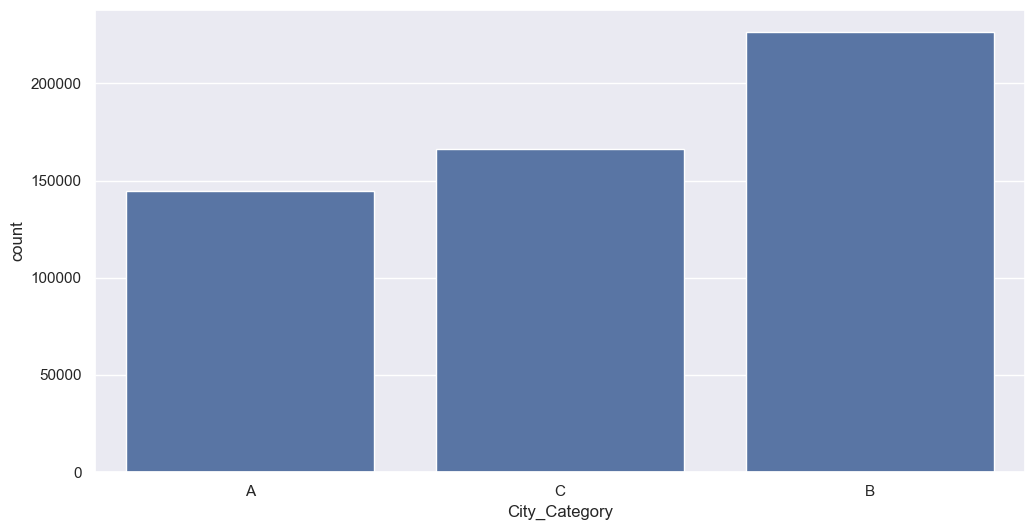

In [50]:
sns.countplot(x = df["City_Category"])

In [58]:
df.groupby("City_Category").size()

City_Category
A    144638
B    226493
C    166446
dtype: int64

<Axes: title={'center': 'Percentage of Purchases from different Cities'}, ylabel='Purchase'>

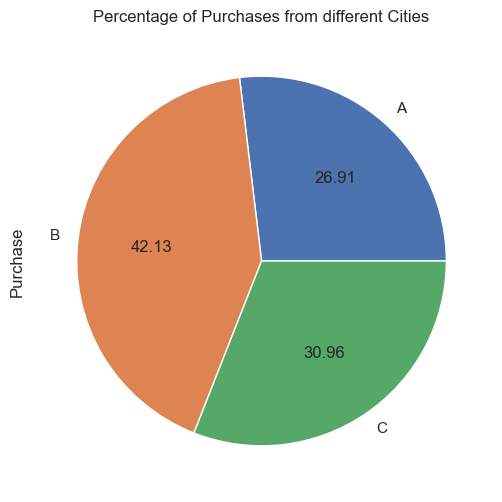

In [90]:
df.groupby("City_Category")["Purchase"].size().plot(kind='pie', autopct='%.2f', title="Percentage of Purchases from different Cities")

Text(0.5, 1.0, 'No. of Persons of Different Age Groups in 3 Cities')

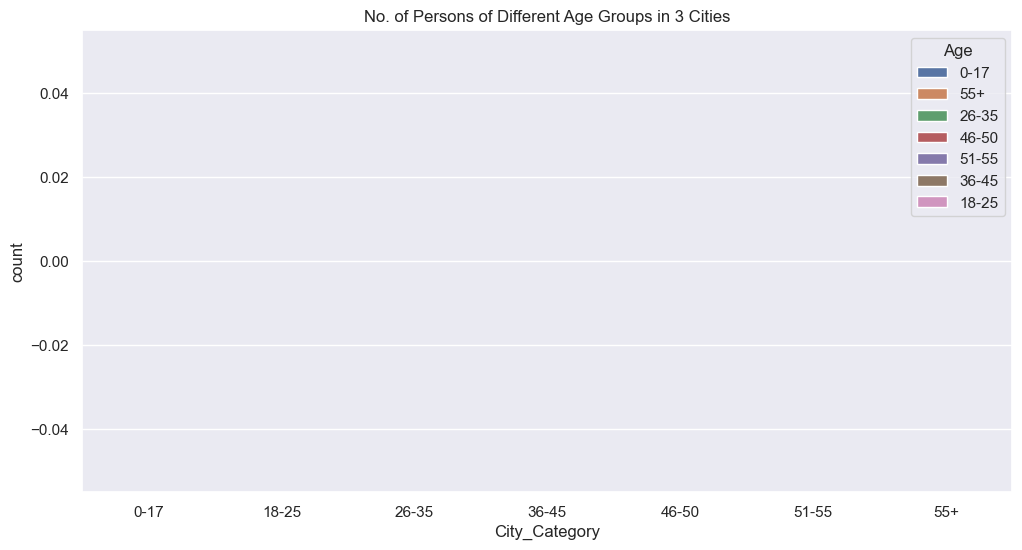

In [74]:
ax = sns.countplot(x = df["City_Category"], hue = df["Age"], order = sorted(df["Age"].unique()), data=df)
ax.set_title("No. of Persons of Different Age Groups in 3 Cities")

## Notice the error, the sorting is applicable for the x parameter, ie., df["City_Category"]
# To get the desired output swap the x and the hue parameter.

Text(0.5, 1.0, 'No. of Persons of Different Age Groups in 3 Cities')

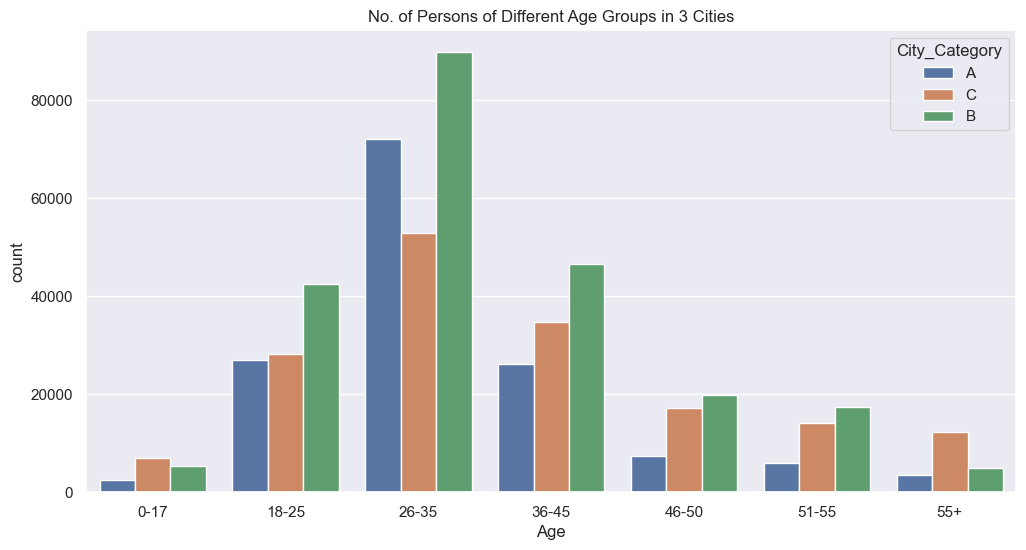

In [80]:
ax = sns.countplot(x = df["Age"], hue = df["City_Category"], order = sorted(df["Age"]))
ax.set_title("No. of Persons of Different Age Groups in 3 Cities")

In [93]:
df.sample(6)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
325074,1002015,P00053842,M,18-25,4,B,4+,0,4,2794
504968,1005787,P00359042,M,26-35,20,B,0,0,2,9526
272240,1005955,P00005142,F,26-35,7,A,1,0,5,5271
251520,1002820,P00318742,F,36-45,0,A,2,0,1,7997
423829,1005252,P00116142,M,26-35,20,B,0,0,10,19117
305319,1005026,P00313342,M,26-35,17,B,1,1,5,7101


In [102]:
data = pd.DataFrame({
    'Sum' : [df[df["City_Category"]==i]["Purchase"].sum() for i in df["City_Category"].unique()] ,
    'Mean' : [df[df["City_Category"]==i]["Purchase"].mean() for i in df["City_Category"].unique()], 
    #'Count' : [len(df[df["City_Category"]==i]) for i in df["City_Category"].unique()]
},
    index = ["City A","City B","City C"])
data

,Sum,Mean
City A,1295668797,8958.011014
City B,1638567969,9844.441855
City C,2083431612,9198.657848


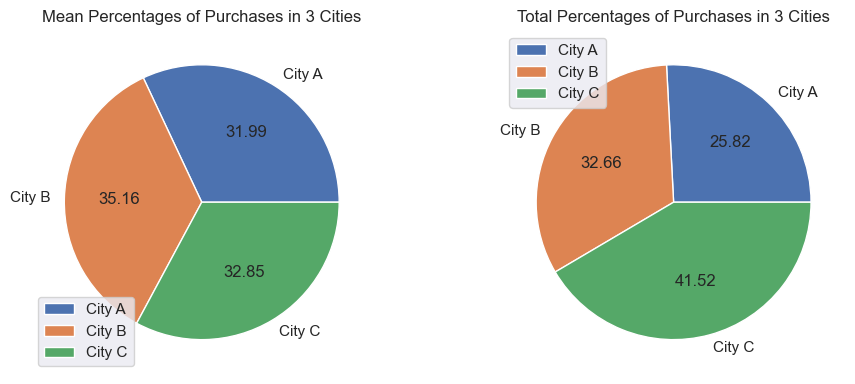

In [106]:
#data.plot(kind='pie', y = 'Mean', autopct="%.2f", title = 'Mean Percentages of Purchases in 3 Cities')
#data.plot(kind='pie', y = 'Sum', autopct="%.2f", title = 'Total Percentages of Purchases in 3 Cities')

import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first pie chart on the first subplot
data.plot(kind='pie', y='Mean', autopct="%.2f", title='Mean Percentages of Purchases in 3 Cities', ax=axes[0])
axes[0].set_ylabel('')  # Remove y-label for cleaner look

# Plot the second pie chart on the second subplot
data.plot(kind='pie', y='Sum', autopct="%.2f", title='Total Percentages of Purchases in 3 Cities', ax=axes[1])
axes[1].set_ylabel('')  # Remove y-label for cleaner look

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

## Occupation and Product Analysis

In [109]:
df.sample(8)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
154804,1005916,P00255942,M,51-55,20,B,1,1,1,15816
454153,1003906,P00120042,M,51-55,17,C,1,0,1,15717
70858,1004872,P00182342,M,46-50,1,C,2,0,1,15691
510626,1000693,P00367042,M,36-45,12,A,4+,1,8,7849
307523,1005394,P0096342,M,18-25,0,A,2,0,8,6166
345351,1005153,P00024642,M,26-35,7,B,3,0,5,5348
283812,1001697,P00190042,F,18-25,4,B,3,0,3,13586
84702,1001101,P00351342,M,36-45,1,A,1,0,1,7586


In [119]:
df['Occupation'].nunique()

21

In [117]:
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6], dtype=int64)

### Finding the category to advertise so as to receive profit

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

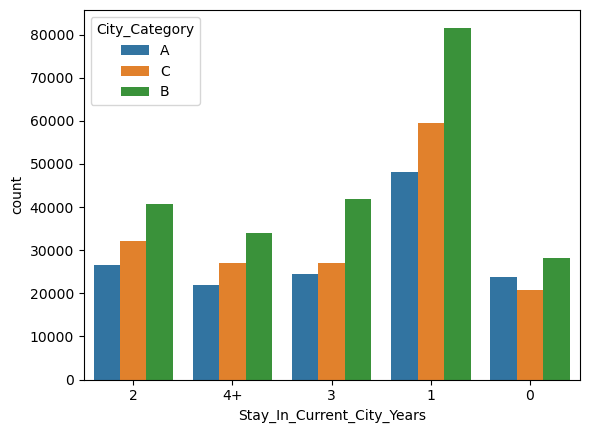

In [15]:
sns.countplot(x="Stay_In_Current_City_Years", hue='City_Category',data=df)
# people with 1 year experience and from City B purchase more

<Axes: xlabel='Occupation', ylabel='count'>

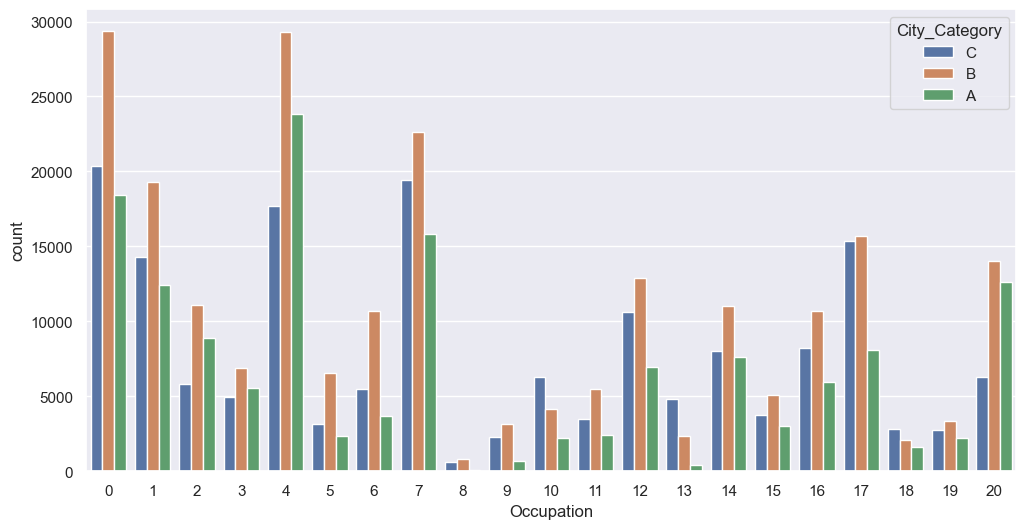

In [128]:
sns.countplot(x='Occupation',hue='City_Category',data=df)

<Axes: xlabel='Occupation', ylabel='count'>

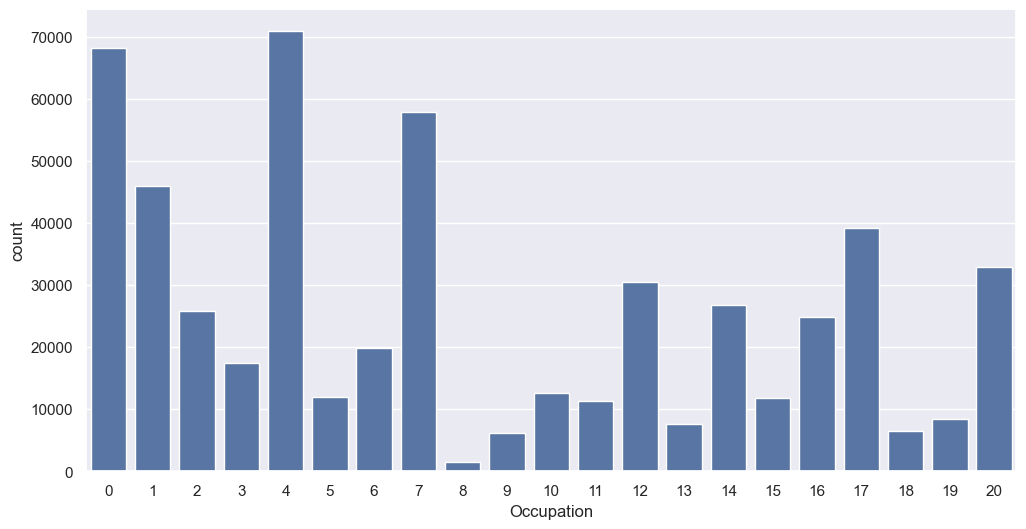

In [164]:
sns.countplot(x='Occupation',data=df)
# Occupation with 0,1,4,7,17 have the highest buyers

In [17]:
df.head()


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


## Which Age Group affliated to which Product Category


<Axes: xlabel='Product_Category_1', ylabel='count'>

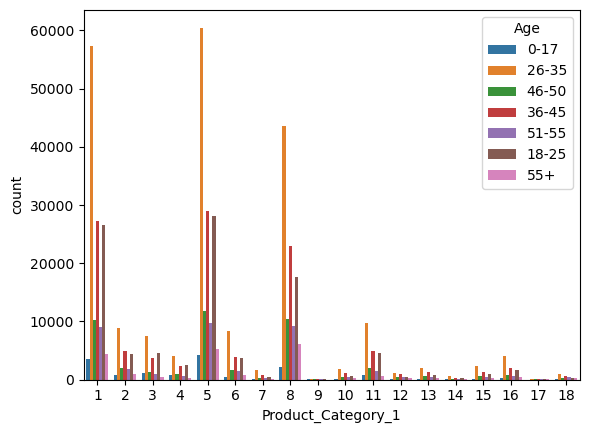

In [28]:
sns.countplot(x='Product_Category_1',hue='Age',data=df)


###  from the bar chart we can infer that product (1,5,8) have the greatest affiliation 
### also 26-35 have the most liking to the above products, while 36-45 and 18-25 have purchased around 30000 products

In [61]:
df.groupby(['Product_Category_1','Age']).size()

Product_Category_1  Age  
1                   0-17      3524
                    18-25    26627
                    26-35    57398
                    36-45    27215
                    46-50    10292
                             ...  
18                  26-35     1021
                    36-45      689
                    46-50      346
                    51-55      420
                    55+        236
Length: 126, dtype: int64

## Finding the products most sold 

In [81]:
df.groupby('Product_ID').size()   # give the no of rows of the specific product

Product_ID
P00000142    1130
P00000242     371
P00000342     238
P00000442      92
P00000542     146
             ... 
P0099442      196
P0099642       13
P0099742      123
P0099842      100
P0099942       13
Length: 3623, dtype: int64

In [85]:
df.groupby('Product_ID').sum()['Purchase']  # gives the total purchase amount of each product

Product_ID
P00000142    12592163
P00000242     3914901
P00000342     1261383
P00000442      441173
P00000542      791219
               ...   
P0099442      2813314
P0099642        83710
P0099742       967072
P0099842       721334
P0099942        70843
Name: Purchase, Length: 3623, dtype: int64

## 10 products with the highest purchase price

<Axes: xlabel='Product_ID'>

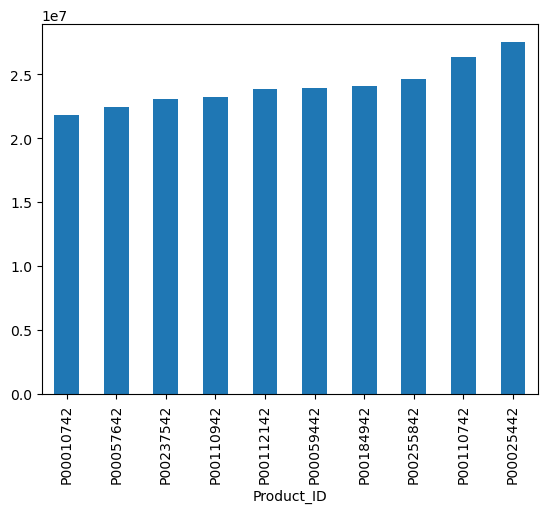

In [92]:
df.groupby('Product_ID').sum()['Purchase'].nlargest(10).sort_values().plot(kind = 'bar')

### the last product has the highest purchase amount for x sales, which are also the highest

## 10 products with the highest no of sales

<Axes: xlabel='Product_ID'>

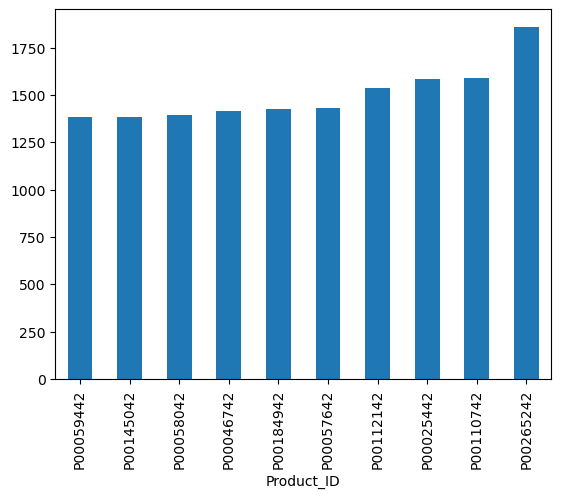

In [94]:
df.groupby('Product_ID').size().nlargest(10).sort_values().plot(kind = 'bar')    

### the last product is listed the most / is sold most

## 10 products with the highest average purchase price

<Axes: xlabel='Product_ID'>

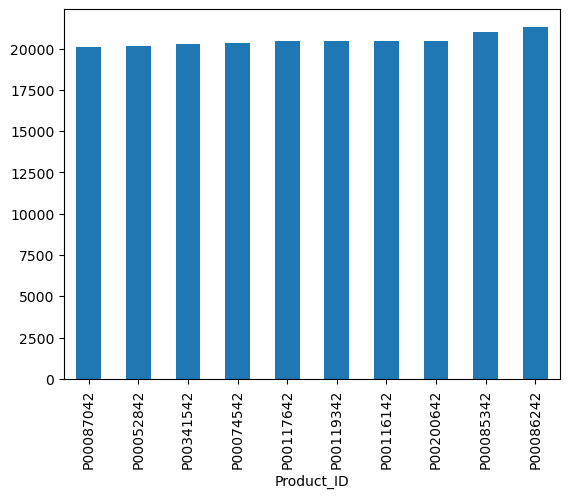

In [110]:
df.groupby('Product_ID')['Purchase'].mean().nlargest(10).sort_values().plot(kind='bar')

# use .mean() after the variable

# Male-Female Ratio -(graphical version)

<Axes: xlabel='Product_Category_1', ylabel='count'>

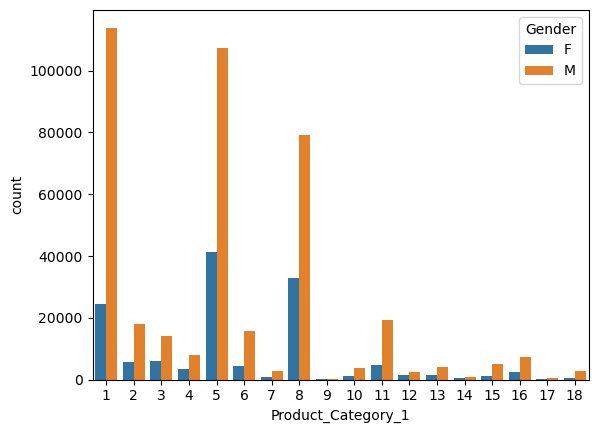

In [117]:
sns.countplot(x='Product_Category_1',hue='Gender',data=df)

# Married:Unmarried Ratio graphical version

<Axes: xlabel='Product_Category_1', ylabel='count'>

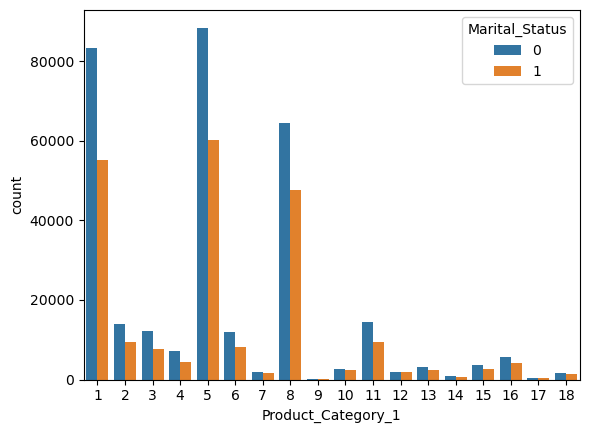

In [119]:
sns.countplot(x='Product_Category_1',hue='Marital_Status',data=df)

# Combining Gender and Marital Status

In [124]:
df.groupby(['Gender','Marital_Status']).size()

Gender  Marital_Status
F       0                  76974
        1                  55223
M       0                 240843
        1                 164537
dtype: int64

In [132]:
df.groupby(['Gender','Marital_Status']).size()

Gender  Marital_Status
F       0                  76974
        1                  55223
M       0                 240843
        1                 164537
dtype: int64

In [ ]:
# Purchase of Male Unmarried
# Purchase of Male Married
# Purchase of Female Unmarried
# Purchase of Female Married

In [11]:
l = []
for i in range(len(df)):
    l.append(df['Gender'][i]+'_'+str(df['Marital_Status'][i]))
df['Marital_Gender'] = l
df.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase,Marital_Gender
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,F_0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,F_0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,F_0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,F_0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,M_0


<Axes: xlabel='Marital_Gender'>

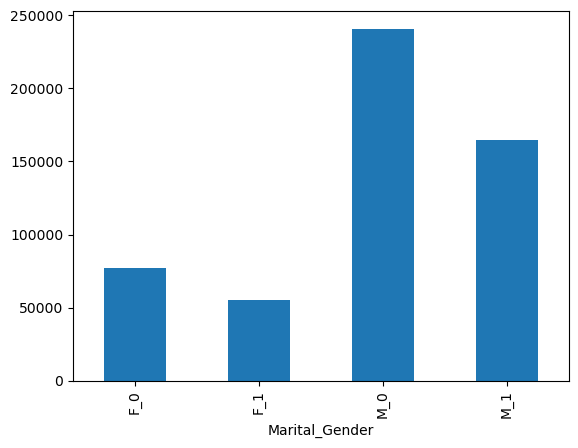

In [140]:
df.groupby('Marital_Gender')['Purchase'].size().plot(kind='bar')

# Marital_Status combined with Gender from Different Age-Groups

<Axes: xlabel='Age', ylabel='count'>

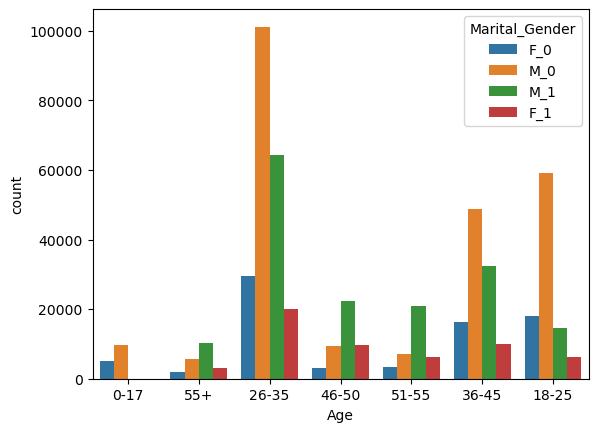

In [13]:
# OR
sns.countplot(x='Age',hue='Marital_Gender',data=df)

# Combination of different Genders with their Marital_Status from different Cities

<Axes: xlabel='City_Category', ylabel='count'>

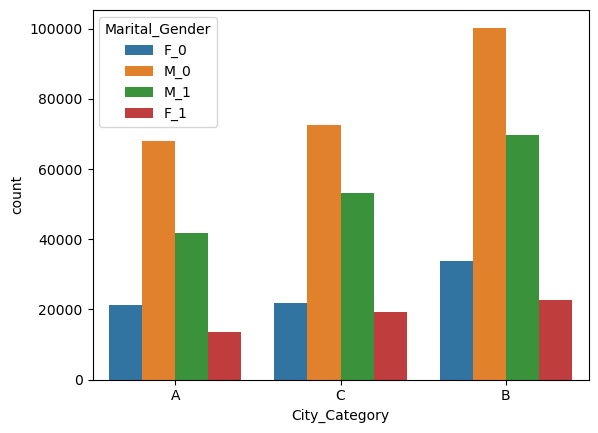

In [16]:
sns.countplot(x='City_Category',hue='Marital_Gender',data=df)